In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-book-foundations.6j_z9po4/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-book-foundations.6j_z9po4/venv", "python": "3.12.14", "torch_cuda_build": null}


# Bradley–Terry: the gradient of a comparison

Day 15 · Chapter 10. CPU, authored synthetic data, no downloads. Predict before each reference, change one declared variable, and interpret the result. Code is complete so the notebook runs from beginning to end. Completing its execution is material verification, not an assessment of learner mastery.

[Canonical chapter](../../book/chapters/10-preferences-and-reward-models.md)


In [2]:
from pathlib import Path
import sys
root = Path.cwd().resolve()
while not (root / "src" / "dongxi_llms").is_dir():
    if root.parent == root:
        raise RuntimeError("Open this notebook within the Dongxi_LLMs repository")
    root = root.parent
sys.path.insert(0, str(root / "src"))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
blue, orange, green = "#356a9b", "#b97139", "#3d8268"



## The route

A prompt and two responses enter the same score function. Their scalar difference becomes one binary logit. The diagram is a schematic; the subsequent curves use actual tensors.


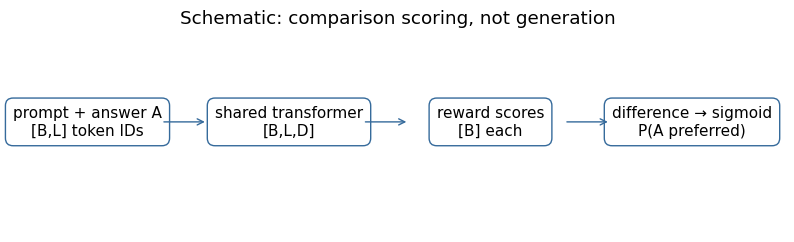

In [3]:
fig, ax = plt.subplots(figsize=(10, 2.6))
boxes = [("prompt + answer A\n[B,L] token IDs", .10), ("shared transformer\n[B,L,D]", .36),
         ("reward scores\n[B] each", .62), ("difference → sigmoid\nP(A preferred)", .88)]
for text, x in boxes:
    ax.text(x, .55, text, ha="center", va="center", bbox=dict(boxstyle="round,pad=.5", facecolor="white", edgecolor=blue))
for x in (.20,.46,.72):
    ax.annotate("", xy=(x+.055,.55), xytext=(x-.005,.55), arrowprops=dict(arrowstyle="->",color=blue))
ax.set(xlim=(0,1),ylim=(0,1)); ax.axis("off"); ax.set_title("Schematic: comparison scoring, not generation")
plt.show()


![Saved reference plot for 01 bradley terry margin, figure 1](../figures/chapter-10/day-15-01_bradley_terry_margin-01.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


### Prediction

## Exercise 1: implement the loss mentally, then inspect the reference

Write a prediction about the derivative at margins −3, 0, and +3 for a winner target. The stable implementation uses softplus rather than log(sigmoid).

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


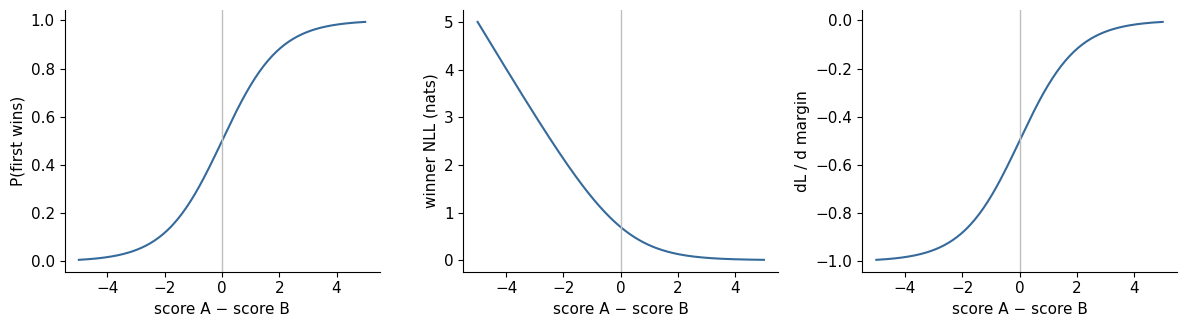

Negative derivative means gradient descent increases the margin.


In [4]:
from dongxi_llms.reward_model_lab import bt_loss
margin = torch.linspace(-5, 5, 201, dtype=torch.float64, requires_grad=True)
losses = bt_loss(margin, torch.zeros_like(margin), reduction="none")
gradient, = torch.autograd.grad(losses.sum(), margin)
torch.testing.assert_close(gradient, margin.sigmoid()-1)
fig, axes = plt.subplots(1,3,figsize=(12,3.4))
for ax, values, ylabel in zip(axes,[margin.detach().sigmoid(),losses.detach(),gradient.detach()],
                              ["P(first wins)","winner NLL (nats)","dL / d margin"]):
    ax.plot(margin.detach(),values,color=blue); ax.axvline(0,color=".75",lw=1)
    ax.set(xlabel="score A − score B",ylabel=ylabel)
plt.tight_layout(); plt.show()
print("Negative derivative means gradient descent increases the margin.")


### Reference explanation

**Read the figure:** probability increases with margin; loss decreases; the signed derivative approaches zero as the winner becomes likely. The gradient is a direction for a scalar margin, before shared-parameter Jacobians.


![Saved reference plot for 01 bradley terry margin, figure 2](../figures/chapter-10/day-15-01_bradley_terry_margin-02.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


### Prediction

## Exercise 2: gauge versus confidence

Predict which transformation changes preference probability: add 50 to both scores, or multiply both by 2. Then run the reference and alter the original scores.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Prediction

**Synthesis prediction:** If both scores increase by 50, does the model become more confident? If the first answer is incorrectly disfavored, which score should gradient descent raise?

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [5]:
a = torch.tensor([.4],dtype=torch.float64,requires_grad=True)
b = torch.tensor([-.6],dtype=torch.float64,requires_grad=True)
original, offset, scaled = bt_loss(a,b), bt_loss(a+50,b+50), bt_loss(2*a,2*b)
torch.testing.assert_close(original,offset)
ga, gb = torch.autograd.grad(original,(a,b))
print({"original_nll":float(original.detach()),"offset_nll":float(offset.detach()),
       "scaled_nll":float(scaled.detach()),"score_gradients":(ga.tolist(),gb.tolist())})


{'original_nll': 0.31326168751822286, 'offset_nll': 0.31326168751822286, 'scaled_nll': 0.1269280110429725, 'score_gradients': ([-0.2689414213699951], [0.2689414213699951])}


### Reference explanation

**Solution:** offsets cancel; scaling changes the margin and confidence. Opposing score gradients do not guarantee that a shared neural model changes only these two answers.

**Evidence boundary:** these are exact binary-likelihood mechanisms. They do not establish that the labels are correct, that one scalar captures every person's preferences, or that a higher raw reward means a better assistant.
